In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right'] = False

# only load the columns the model actually needs — saves ~60% RAM
MODEL_COLS = [
    'loan_amnt', 'int_rate', 'installment',
    'dti', 'fico_mid', 'revol_util',
    'delinq_2yrs', 'open_acc', 'annual_inc',
    'log_annual_inc', 'payment_to_income',
    'credit_util_ratio', 'has_delinquency', 'term',
    'grade', 'home_ownership', 'verification_status', 'purpose',
    'default_flag', 'issue_d'
]
# usecols loads only these columns — never reads the rest into RAM
df = pd.read_csv(
    '../outputs/featured_loans.csv',
    usecols=[c for c in MODEL_COLS],
)

# downcast numeric columns to float32 — halves memory vs float64
float_cols = df.select_dtypes(include=['float64']).columns
int_cols   = df.select_dtypes(include=['int64']).columns
df[float_cols] = df[float_cols].astype('float32')
df[int_cols]   = df[int_cols].astype('int32')

df['issue_d'] = pd.to_datetime(df['issue_d'])

# force garbage collection — clears anything left from previous runs
gc.collect()

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Loaded  : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"RAM used: {mem_mb:.1f} MB")
print(f"Default rate: {df['default_flag'].mean()*100:.1f}%")

Loaded  : 265,776 rows × 20 cols
RAM used: 79.2 MB
Default rate: 20.1%


In [3]:
NUM_FEATURES = [
    'loan_amnt', 'int_rate', 'installment',
    'dti', 'fico_mid', 'revol_util',
    'delinq_2yrs', 'open_acc', 'annual_inc',
    'log_annual_inc', 'payment_to_income',
    'credit_util_ratio', 'has_delinquency', 'term'
]
CAT_FEATURES = ['grade', 'home_ownership',
                'verification_status', 'purpose']
TARGET = 'default_flag'

cols_needed = NUM_FEATURES + CAT_FEATURES + [TARGET]
df_model    = df[cols_needed].dropna().copy()

# free original df from RAM immediately after slicing
del df
gc.collect()

df_encoded = pd.get_dummies(df_model, columns=CAT_FEATURES, drop_first=True)
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f"X shape : {X.shape}")
print(f"RAM after encoding: {X.memory_usage(deep=True).sum()/1e6:.1f} MB")

X shape : (265665, 37)
RAM after encoding: 23.1 MB


In [4]:
# 80/20 split, stratified to preserve the 20% default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # critical — ensures class balance in both splits
)

print(f"Train size : {X_train.shape[0]:,}  |  default rate: {y_train.mean()*100:.1f}%")
print(f"Test size  : {X_test.shape[0]:,}   |  default rate: {y_test.mean()*100:.1f}%")

Train size : 212,532  |  default rate: 20.1%
Test size  : 53,133   |  default rate: 20.1%


In [5]:
# Pipeline: StandardScaler → LogisticRegression
# Scaler ensures features with large ranges (loan_amnt, annual_inc)
# don't dominate features with small ranges (dti, revol_util)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight='balanced',  # handles 80/20 class imbalance
        max_iter=1000,             # enough iterations to converge
        random_state=42,
        solver='lbfgs'
    ))
])

pipeline.fit(X_train, y_train)
print("Model trained ✓")

# cross-validation AUC (5-fold) — more reliable than single train/test
cv_scores = cross_val_score(pipeline, X_train, y_train,
                             cv=5, scoring='roc_auc')
print(f"5-fold CV AUC scores : {cv_scores.round(3)}")
print(f"Mean CV AUC          : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Model trained ✓
5-fold CV AUC scores : [0.732 0.737 0.739 0.735 0.734]
Mean CV AUC          : 0.736 ± 0.003


In [6]:
#Why Pipeline: Wrapping scaler + model in a Pipeline means the scaler is fitted only on training data, then applied to test data — prevents data leakage. Always use Pipeline. 

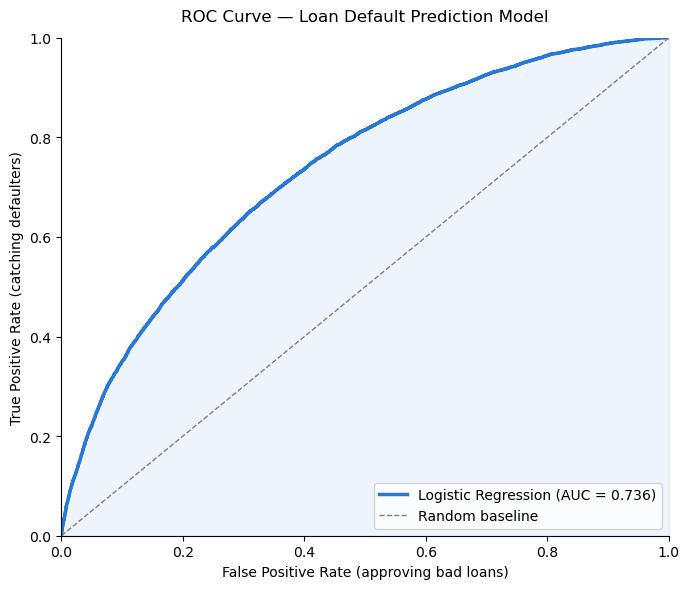


Test AUC : 0.736
Baseline : 0.500 (random)
Target   : ≥0.720 (Phase 1 KPI)
Status   : ✓ KPI MET


In [7]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred       = pipeline.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2a78d6', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], '--', color='gray', linewidth=1, label='Random baseline')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2a78d6')
ax.set_xlabel('False Positive Rate (approving bad loans)')
ax.set_ylabel('True Positive Rate (catching defaulters)')
ax.set_title('ROC Curve — Loan Default Prediction Model', pad=12)
ax.legend(loc='lower right')
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig('../outputs/chart8_roc_curve.png', dpi=150)
plt.show()

print(f"\nTest AUC : {auc:.3f}")
print(f"Baseline : 0.500 (random)")
print(f"Target   : ≥0.720 (Phase 1 KPI)")
print(f"Status   : {'✓ KPI MET' if auc >= 0.72 else '✗ below target'}")

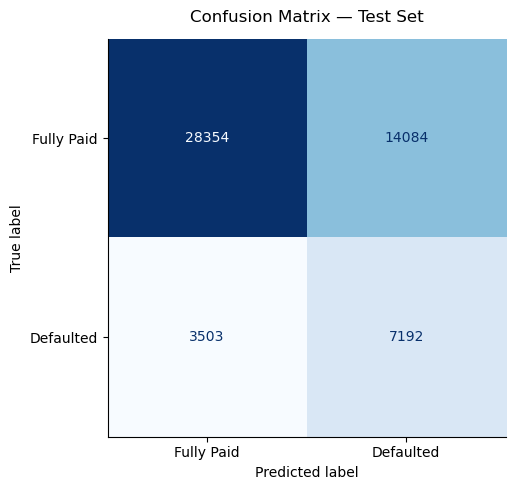


True  Positives (correctly flagged defaults) : 7,192
False Positives (good loans wrongly flagged) : 14,084
False Negatives (missed defaults)            : 3,503
True  Negatives (correctly approved)         : 28,354

Precision : 0.338  (of flagged loans, how many actually defaulted)
Recall    : 0.672  (of actual defaults, how many did we catch)
F1 Score  : 0.450
Recall KPI: ✗ below 0.70 target


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fully Paid', 'Defaulted']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', pad=12)
plt.tight_layout()
plt.savefig('../outputs/chart9_confusion_matrix.png', dpi=150)
plt.show()

# extract values
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)   # = sensitivity = default detection rate
f1        = 2 * precision * recall / (precision + recall)

print(f"\nTrue  Positives (correctly flagged defaults) : {tp:,}")
print(f"False Positives (good loans wrongly flagged) : {fp:,}")
print(f"False Negatives (missed defaults)            : {fn:,}")
print(f"True  Negatives (correctly approved)         : {tn:,}")
print(f"\nPrecision : {precision:.3f}  (of flagged loans, how many actually defaulted)")
print(f"Recall    : {recall:.3f}  (of actual defaults, how many did we catch)")
print(f"F1 Score  : {f1:.3f}")
print(f"Recall KPI: {'✓ MET' if recall >= 0.70 else '✗ below 0.70 target'}")

Top 15 features by absolute coefficient:
                            feature  coefficient  odds_ratio
                           int_rate     0.504777    1.656617
                               term     0.424518    1.528854
                          loan_amnt    -0.318660    0.727123
                        installment     0.261367    1.298704
                           fico_mid    -0.188573    0.828140
                            grade_C     0.162143    1.176029
                                dti     0.137491    1.147391
                            grade_B     0.131367    1.140386
                  payment_to_income     0.097455    1.102362
                            grade_D     0.089388    1.093505
                home_ownership_RENT     0.079272    1.082498
            home_ownership_MORTGAGE    -0.078721    0.924298
       verification_status_Verified     0.073051    1.075785
                           open_acc     0.065871    1.068089
verification_status_Source Verified     0.05

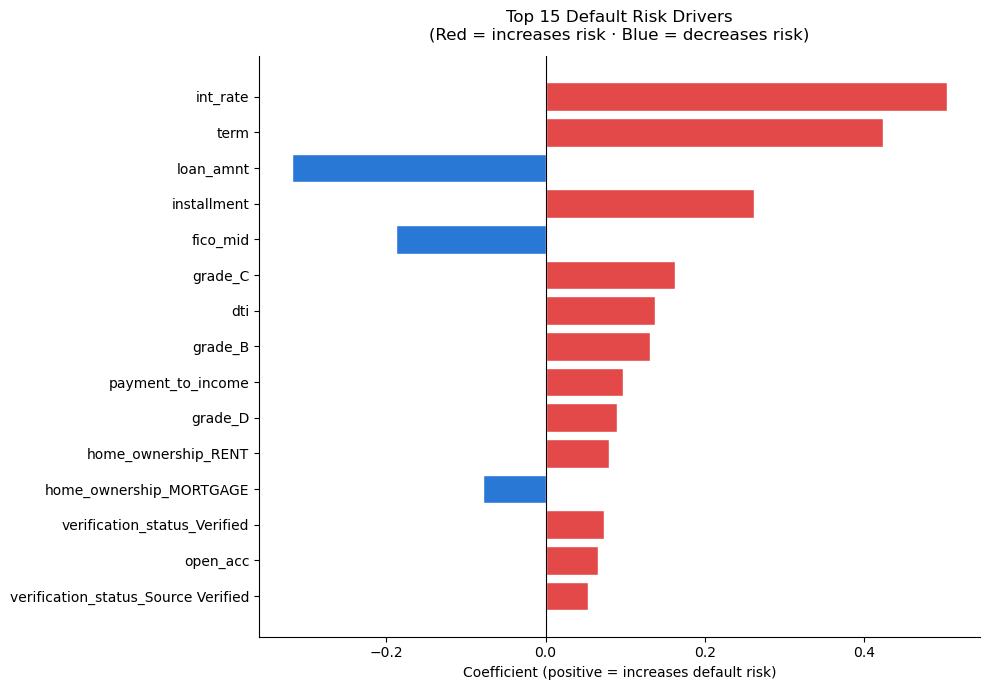

In [9]:
# extract coefficients from the logistic regression inside the pipeline
model   = pipeline.named_steps['model']
scaler  = pipeline.named_steps['scaler']

coef_df = pd.DataFrame({
    'feature'    : X.columns,
    'coefficient': model.coef_[0],
    'odds_ratio' : np.exp(model.coef_[0])
}).sort_values('coefficient', key=abs, ascending=False).head(15)

print("Top 15 features by absolute coefficient:")
print(coef_df.to_string(index=False))

# plot top 15
fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e34948' if c > 0 else '#2a78d6'
           for c in coef_df['coefficient']]

ax.barh(coef_df['feature'], coef_df['coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = increases default risk)')
ax.set_title('Top 15 Default Risk Drivers\n(Red = increases risk · Blue = decreases risk)',
             pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/chart10_feature_importance.png', dpi=150)
plt.show()

Risk Tier Framework:
           loan_count  actual_default_rate  avg_prob
risk_tier                                           
Green           17010                  2.8      11.9
Amber           53154                  7.0      22.5
Red            195501                 25.2      53.9


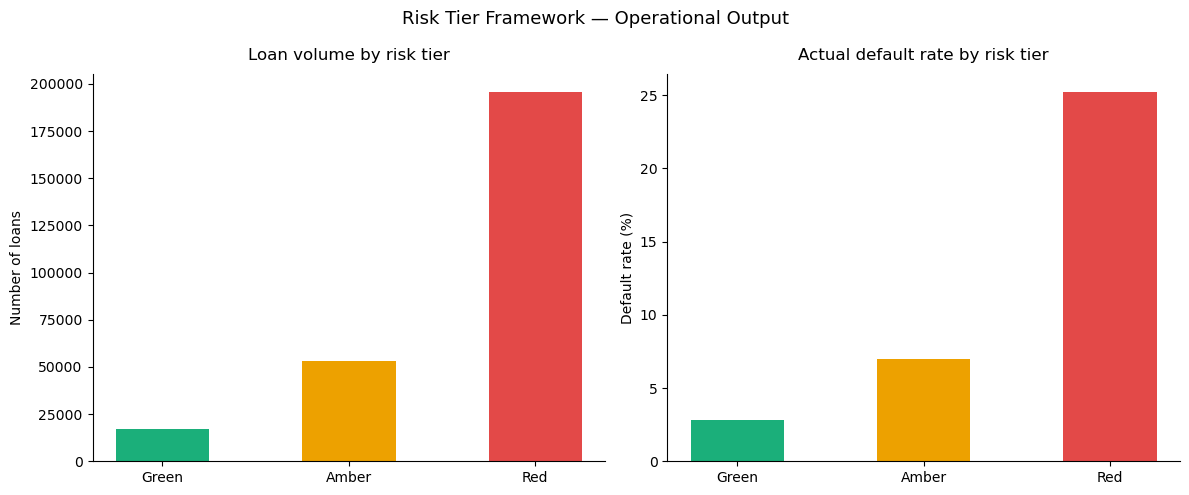

In [10]:
# assign each loan a risk tier based on predicted default probability
# this is the operational output — what the credit team actually uses

df_model['default_prob'] = pipeline.predict_proba(X)[:, 1]

df_model['risk_tier'] = pd.cut(
    df_model['default_prob'],
    bins=[0, 0.15, 0.30, 1.0],
    labels=['Green', 'Amber', 'Red']
)

tier_summary = (
    df_model.groupby('risk_tier', observed=True)
    .agg(
        loan_count   =('default_flag', 'count'),
        actual_default_rate=('default_flag', 'mean'),
        avg_prob     =('default_prob', 'mean')
    )
    .assign(actual_default_rate=lambda x: (x['actual_default_rate']*100).round(1))
    .assign(avg_prob=lambda x: (x['avg_prob']*100).round(1))
)

print("Risk Tier Framework:")
print(tier_summary.to_string())

# visualise tier distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_counts = df_model['risk_tier'].value_counts().reindex(['Green','Amber','Red'])
axes[0].bar(tier_counts.index, tier_counts.values,
            color=['#1baf7a','#eda100','#e34948'], width=0.5)
axes[0].set_title('Loan volume by risk tier', pad=10)
axes[0].set_ylabel('Number of loans')

axes[1].bar(tier_summary.index,
            tier_summary['actual_default_rate'],
            color=['#1baf7a','#eda100','#e34948'], width=0.5)
axes[1].set_title('Actual default rate by risk tier', pad=10)
axes[1].set_ylabel('Default rate (%)')
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Risk Tier Framework — Operational Output', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/chart11_risk_tiers.png', dpi=150)
plt.show()

In [11]:
import json

# model performance card
model_card = {
    'project'        : 'Loan Default Risk Intelligence System',
    'model'          : 'Logistic Regression (sklearn)',
    'train_rows'     : int(X_train.shape[0]),
    'test_rows'      : int(X_test.shape[0]),
    'features_used'  : int(X.shape[1]),
    'test_auc'       : round(float(auc), 3),
    'cv_auc_mean'    : round(float(cv_scores.mean()), 3),
    'cv_auc_std'     : round(float(cv_scores.std()), 3),
    'precision'      : round(float(precision), 3),
    'recall'         : round(float(recall), 3),
    'f1_score'       : round(float(f1), 3),
    'class_weight'   : 'balanced',
    'auc_kpi_met'    : bool(auc >= 0.72),
    'recall_kpi_met' : bool(recall >= 0.70),
}

with open('../outputs/model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Model card saved ✓")
print(json.dumps(model_card, indent=2))

# save predictions with risk tiers
df_model[['default_flag', 'default_prob', 'risk_tier']].to_csv(
    '../outputs/loan_predictions.csv', index=False
)
print("Predictions saved ✓")

Model card saved ✓
{
  "project": "Loan Default Risk Intelligence System",
  "model": "Logistic Regression (sklearn)",
  "train_rows": 212532,
  "test_rows": 53133,
  "features_used": 37,
  "test_auc": 0.736,
  "cv_auc_mean": 0.736,
  "cv_auc_std": 0.003,
  "precision": 0.338,
  "recall": 0.672,
  "f1_score": 0.45,
  "class_weight": "balanced",
  "auc_kpi_met": true,
  "recall_kpi_met": false
}
Predictions saved ✓
